In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE

vectorizer = TfidfVectorizer(max_features=1000)
X_yt_vectorized = vectorizer.fit_transform(youtube_comments_true_df['Comment']).toarray()

y_yt = youtube_comments_true_df['true_labels']

smote = SMOTE(random_state=42)
X_resampled_yt, y_resampled_yt = smote.fit_resample(X_yt_vectorized, y_yt)


resampled_df = pd.DataFrame(X_resampled_yt, columns=vectorizer.get_feature_names_out())
resampled_df['true_labels'] = y_resampled_yt




In [12]:
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

#load the CSV files with true labels
youtube_comments_true_df = pd.read_csv("/content/yt_comments_with_labels_updated.csv")
#reddit_comments_true_df = pd.read_csv("/content/reddit_true_labels_updated.csv")

#load the CSV files with predicted labels
#reddit_comments_pred_df = pd.read_csv("/content/reddit_comments_with_labels.csv")

#extract true labels and predictions
labels_yt = youtube_comments_true_df['true_labels'].values
predictions_yt = youtube_comments_true_df['predicted_label'].values

#labels_red = reddit_comments_true_df['true_labels'].values
#predictions_red = reddit_comments_pred_df['predicted_label'].values

#calculate metrics for youtube comments
accuracy_yt = accuracy_score(labels_yt, predictions_yt)
precision_yt = precision_score(labels_yt, predictions_yt, pos_label=1, average='binary')
recall_yt = recall_score(labels_yt, predictions_yt, pos_label=1, average='binary')
f1_yt = f1_score(labels_yt, predictions_yt, pos_label=1, average='binary')

#calculate metrics for reddit comments
#accuracy_red = accuracy_score(labels_red, predictions_red)
#precision_red = precision_score(labels_red, predictions_red, pos_label=1, average='binary')
#recall_red = recall_score(labels_red, predictions_red, pos_label=1, average='binary')
#f1_red = f1_score(labels_red, predictions_red, pos_label=1, average='binary')

# Print metrics
print("YouTube Comments Metrics:")
print(f"Accuracy: {accuracy_yt:.2f}")
print(f"Precision: {precision_yt:.2f}")
print(f"Recall: {recall_yt:.2f}")
print(f"F1 Score: {f1_yt:.2f}")

#print("\nReddit Comments Metrics:")
#print(f"Accuracy: {accuracy_red:.2f}")
#print(f"Precision: {precision_red:.2f}")
#print(f"Recall: {recall_red:.2f}")
#print(f"F1 Score: {f1_red:.2f}")


YouTube Comments Metrics:
Accuracy: 0.99
Precision: 0.11
Recall: 1.00
F1 Score: 0.19


In [7]:
#check class distribution
print("YouTube True Label Distribution:")
print(pd.Series(labels_yt).value_counts())

print("\nYouTube Predicted Label Distribution:")
print(pd.Series(predictions_yt).value_counts())

print("\nReddit True Label Distribution:")
print(pd.Series(labels_red).value_counts())

print("\nReddit Predicted Label Distribution:")
print(pd.Series(predictions_red).value_counts())

#classification report
print("\nYouTube Classification Report:")
print(classification_report(labels_yt, predictions_yt, target_names=["Non-racist", "Racist"]))

#print("\nReddit Classification Report:")
#print(classification_report(labels_red, predictions_red, target_names=["Non-racist", "Racist"]))


YouTube True Label Distribution:
0    53272
1       48
Name: count, dtype: int64

YouTube Predicted Label Distribution:
0    52873
1      447
Name: count, dtype: int64

Reddit True Label Distribution:
0    1219000
Name: count, dtype: int64

Reddit Predicted Label Distribution:
0    1210331
1       8669
Name: count, dtype: int64

YouTube Classification Report:
              precision    recall  f1-score   support

  Non-racist       1.00      0.99      1.00     53272
      Racist       0.11      1.00      0.19        48

    accuracy                           0.99     53320
   macro avg       0.55      1.00      0.60     53320
weighted avg       1.00      0.99      1.00     53320


Reddit Classification Report:


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

  Non-racist       1.00      0.99      1.00   1219000
      Racist       0.00      0.00      0.00         0

    accuracy                           0.99   1219000
   macro avg       0.50      0.50      0.50   1219000
weighted avg       1.00      0.99      1.00   1219000



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


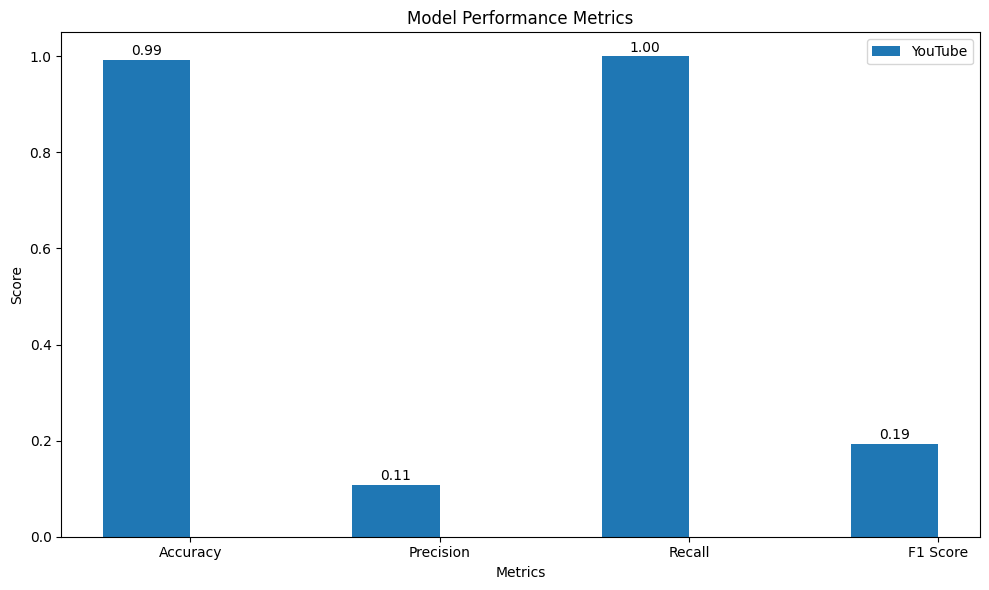

In [6]:
import matplotlib.pyplot as plt
import numpy as np

#metrics for YouTube and Reddit
metrics_yt = [accuracy_yt, precision_yt, recall_yt, f1_yt]
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

# X-axis positions
x = np.arange(len(metric_names))

# Plot settings
width = 0.35  # Bar width
fig, ax = plt.subplots(figsize=(10, 6))

# Plot YouTube and Reddit metrics
ax.bar(x - width/2, metrics_yt, width, label='YouTube')


# Add labels and title
ax.set_xlabel('Metrics')
ax.set_ylabel('Score')
ax.set_title('Model Performance Metrics')
ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.legend()

# Annotate bars with values
for i, v in enumerate(metrics_yt):
    ax.text(i - width/2, v + 0.01, f"{v:.2f}", ha='center')
#for i, v in enumerate(metrics_red):
    #ax.text(i + width/2, v + 0.01, f"{v:.2f}", ha='center')

# Show plot
plt.tight_layout()
plt.show()


In [ ]:
# Use weighted metrics to account for imbalance
from sklearn.metrics import classification_report

print("\nYouTube Weighted Classification Report:")
print(classification_report(labels_yt, predictions_yt, target_names=["Non-racist", "Racist"], zero_division=1))

#print("\nReddit Weighted Classification Report:")
#print(classification_report(labels_red, predictions_red, target_names=["Non-racist", "Racist"], zero_division=1))
